# Malware Detection Model Training

This notebook contains the complete pipeline for training the malware detection model.

## 1. Imports and Setup

In [1]:
import os
import json
import logging
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import sys
sys.path.append('.')
from model import MalwareDetectionModel, GatedCNN
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

## 2. Data Loading Components

In [2]:
class MalwareDataset(Dataset):
    """
    A memory-efficient PyTorch Dataset for loading malware features.
    """
    def __init__(self, file_paths, labels, api_seq_len=500):
        self.file_paths = file_paths
        self.labels = labels
        self.api_seq_len = api_seq_len

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        paths = self.file_paths[idx]
        label = self.labels[idx]

        api_features = np.load(paths['apis'])
        global_features = np.load(paths['globals'])

        seq_len, num_features = api_features.shape
        if seq_len > self.api_seq_len:
            api_features = api_features[:self.api_seq_len, :]
        elif seq_len < self.api_seq_len:
            padding = np.zeros((self.api_seq_len - seq_len, num_features))
            api_features = np.vstack((api_features, padding))

        api_tensor = torch.from_numpy(api_features).float()
        global_tensor = torch.from_numpy(global_features).float()
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return (api_tensor, global_tensor), label_tensor

## 3. Model Architecture

We are importing model architecture from model.py script 

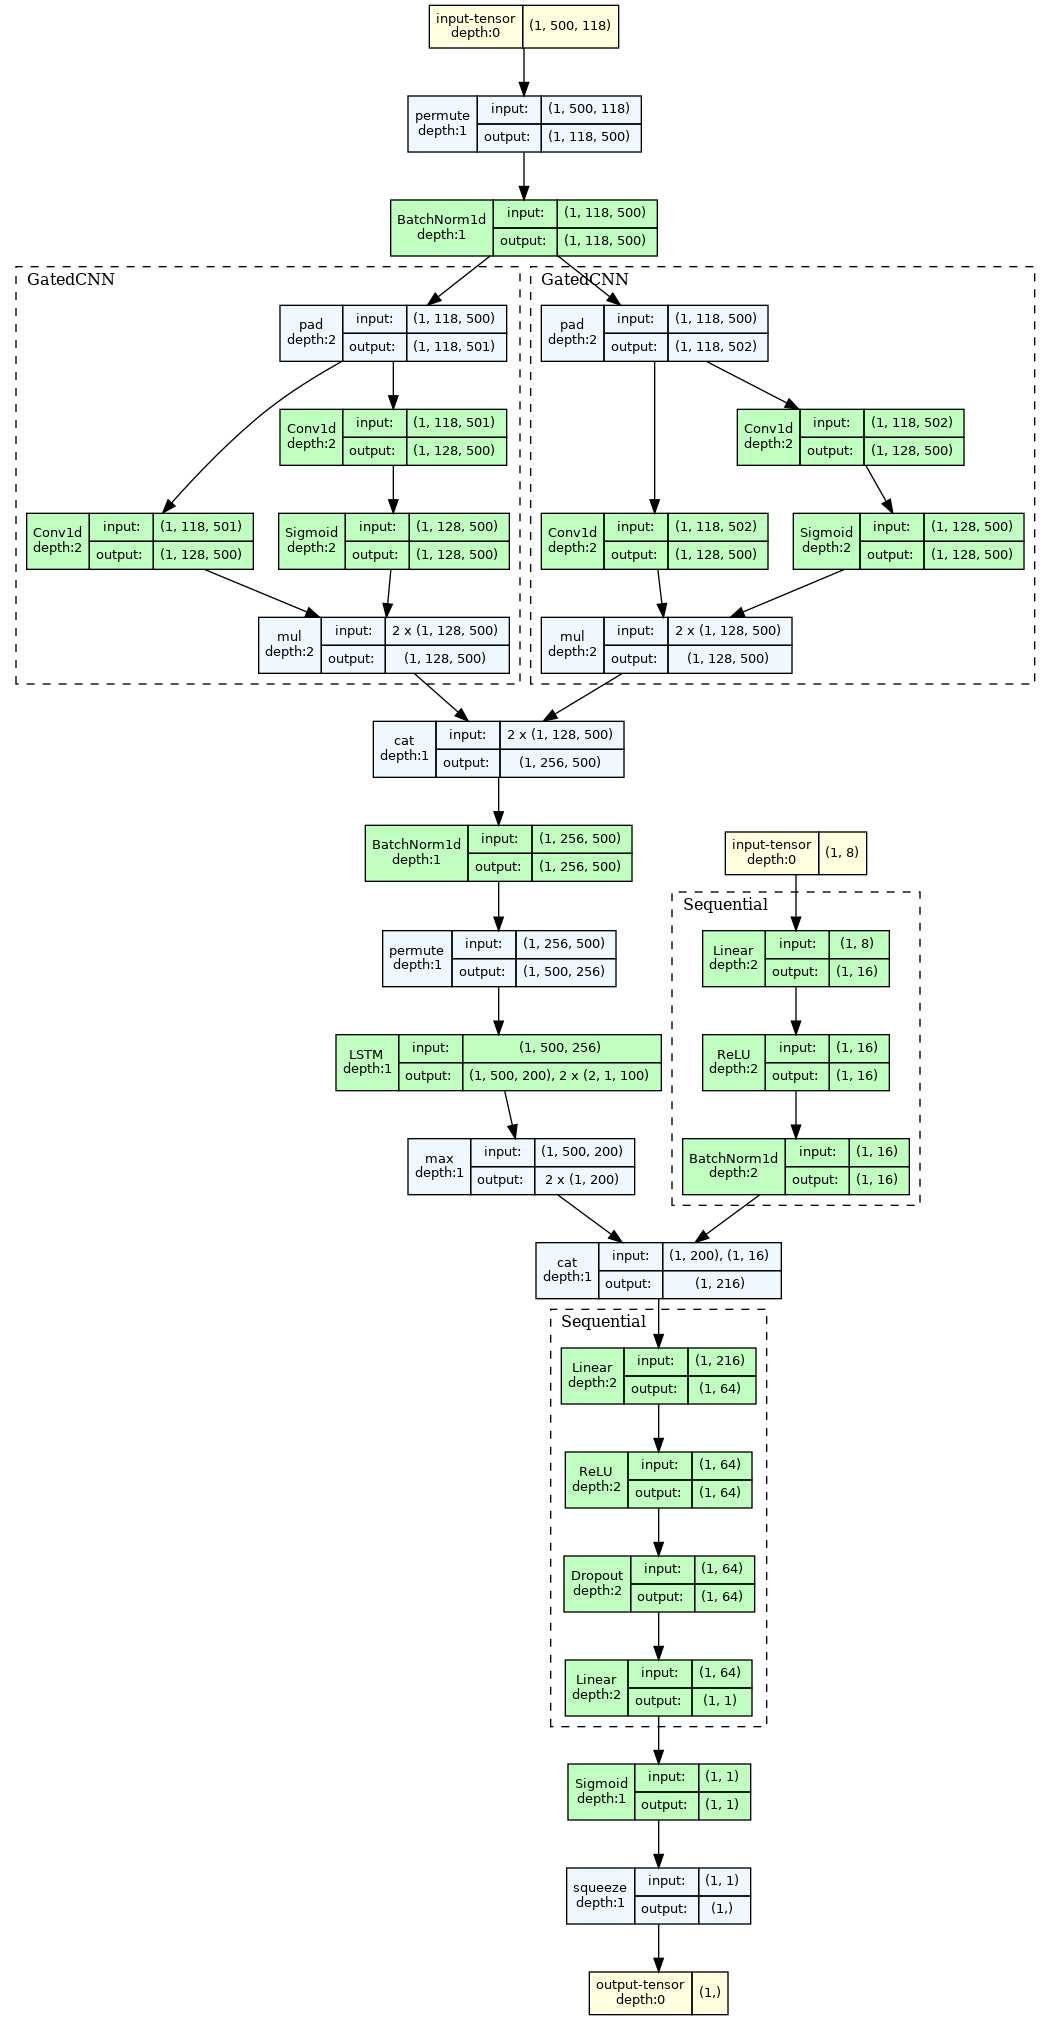

## 4. Training and Validation Functions

In [3]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    for (api_batch, global_batch), labels_batch in train_loader:
        api_batch, global_batch, labels_batch = api_batch.to(device), global_batch.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(api_batch, global_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * api_batch.size(0)
        predicted = (outputs > 0.5).float()
        correct_predictions += (predicted == labels_batch).sum().item()
        total_samples += labels_batch.size(0)
    return total_loss / total_samples, correct_predictions / total_samples

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for (api_batch, global_batch), labels_batch in val_loader:
            api_batch, global_batch, labels_batch = api_batch.to(device), global_batch.to(device), labels_batch.to(device)
            outputs = model(api_batch, global_batch)
            loss = criterion(outputs, labels_batch)
            total_loss += loss.item() * api_batch.size(0)
            predicted = (outputs > 0.5).float()
            correct_predictions += (predicted == labels_batch).sum().item()
            total_samples += labels_batch.size(0)
    return total_loss / total_samples, correct_predictions / total_samples

## 5. Main Training Execution

In [4]:
# --- Configuration ---
DATA_DIR = '.'
OUTPUT_DIR = '.'
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_WORKERS = 2
NO_CUDA = False

# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() and not NO_CUDA else "cpu")
logging.info(f"Using device: {device}")

# --- Data Loading ---
splits_path = os.path.join(DATA_DIR, 'dataset_splits.json')
with open(splits_path, 'r') as f:
    splits = json.load(f)

train_dataset = MalwareDataset(splits['train']['files'], splits['train']['labels'])
val_dataset = MalwareDataset(splits['validation']['files'], splits['validation']['labels'])
# Show dataset information
print(f"Dataset Information:")
print(f"- Training samples: {len(train_dataset)}")
print(f"- Validation samples: {len(val_dataset)}")

# Show class distribution in training set
train_labels = splits['train']['labels']
benign_count = train_labels.count(0)
malware_count = train_labels.count(1)
print(f"- Training class distribution: Benign: {benign_count}, Malware: {malware_count}")


2025-12-30 14:31:16,866 - INFO - Using device: cuda


Dataset Information:
- Training samples: 28876
- Validation samples: 7220
- Training class distribution: Benign: 15636, Malware: 13240


This is training without normalized datasets

In [5]:

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
logging.info("Data loaders created.")
logging.info(f"{len(train_dataset)} number of training datasets loaded")
logging.info(f"{len(val_dataset)} number of validation datasets loaded")
# --- Model Initialization ---
model = MalwareDetectionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss()
logging.info("Model initialized.")

# --- Training Loop ---
best_val_accuracy = 0.0
output_model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
os.makedirs(OUTPUT_DIR, exist_ok=True)


2025-11-04 10:47:23,431 - INFO - Data loaders created.
2025-11-04 10:47:23,435 - INFO - 28876 number of training datasets loaded
2025-11-04 10:47:23,442 - INFO - 7220 number of validation datasets loaded
2025-11-04 10:47:31,086 - INFO - Model initialized.


In [ ]:

logging.info("Starting training...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), output_model_path)
        logging.info(f"Validation accuracy improved. Saving model to {output_model_path}")

logging.info("Training finished.")
logging.info(f"Best validation accuracy: {best_val_accuracy:.4f}")

## 6. Evaluation on Test Set

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# --- Test Data Loading ---
test_dataset = MalwareDataset(splits['test']['files'], splits['test']['labels'])
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
logging.info(f"{len(test_dataset)} number of test datasets loaded")

2025-12-30 14:31:40,649 - INFO - 9025 number of test datasets loaded


In [7]:
# --- Load Trained Model ---
model = MalwareDetectionModel().to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

MalwareDetectionModel(
  (seq_bn1): BatchNorm1d(118, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gated_cnn2): GatedCNN(
    (conv_out): Conv1d(118, 128, kernel_size=(2,), stride=(1,))
    (conv_gate): Conv1d(118, 128, kernel_size=(2,), stride=(1,))
    (sigmoid): Sigmoid()
  )
  (gated_cnn3): GatedCNN(
    (conv_out): Conv1d(118, 128, kernel_size=(3,), stride=(1,))
    (conv_gate): Conv1d(118, 128, kernel_size=(3,), stride=(1,))
    (sigmoid): Sigmoid()
  )
  (seq_bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bilstm): LSTM(256, 100, batch_first=True, bidirectional=True)
  (global_mlp): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=216, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(

In [8]:
def test_model(model, test_loader, device):
    all_preds = []
    
    all_labels = []
    with torch.no_grad():
        for (api_batch, global_batch), labels_batch in test_loader:
            api_batch, global_batch, labels_batch = api_batch.to(device), global_batch.to(device), labels_batch.to(device)
            outputs = model(api_batch, global_batch)
            predicted = (outputs > 0.5).float()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
    return all_preds, all_labels

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99      4887
     Malware       1.00      0.99      0.99      4138

    accuracy                           0.99      9025
   macro avg       0.99      0.99      0.99      9025
weighted avg       0.99      0.99      0.99      9025



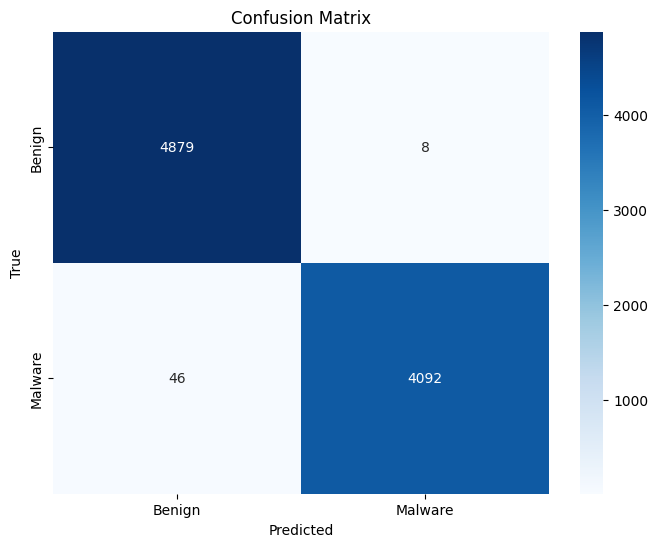

In [9]:
# --- Run Evaluation ---
predictions, true_labels = test_model(model, test_loader, device)

print("Classification Report:")
print(classification_report(true_labels, predictions, target_names=['Benign', 'Malware']))


cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

This model is not suitable to attack as epsilion value for our attack parameter for unnormalized data cannot be calculated or same 

## 7. Training with Noramalized input data


Since our Model has Global max pooling and to attack with Fgsm and pgd we need to noramlize our datasets

In [13]:
import json

def calculate_statistics(file_paths):
    """
    Calculates the mean and standard deviation for API and Global features
    across the entire training dataset.
    """
    logging.info("Calculating dataset statistics for normalization...")
    
    api_sum = None
    api_sq_sum = None
    api_count = 0
    
    global_sum = None
    global_sq_sum = None
    global_count = 0
    
    total_files = len(file_paths)
    for i, paths in enumerate(file_paths):
        if i % 100 == 0:
            print(f"Processing {i}/{total_files}...", end='\r')
            
        # Load data
        api_features = np.load(paths['apis']).astype(np.float32)
        global_features = np.load(paths['globals']).astype(np.float32)
        
        # --- API Features Statistics ---
        # Initialize accumulators if first iteration
        if api_sum is None:
            api_sum = np.zeros(api_features.shape[1])
            api_sq_sum = np.zeros(api_features.shape[1])
            
        # Accumulate sum and squared sum
        api_sum += np.sum(api_features, axis=0)
        api_sq_sum += np.sum(api_features ** 2, axis=0)
        api_count += api_features.shape[0] # Add total number of time steps (rows)
        
        # --- Global Features Statistics ---
        if global_sum is None:
            global_sum = np.zeros(global_features.shape[0])
            global_sq_sum = np.zeros(global_features.shape[0])
            
        global_sum += global_features
        global_sq_sum += global_features ** 2
        global_count += 1
        
    # Calculate Mean and Std
    api_mean = api_sum / api_count
    api_std = np.sqrt((api_sq_sum / api_count) - (api_mean ** 2))
    
    # Avoid division by zero by replacing 0 std with 1
    api_std[api_std == 0] = 1.0
    
    global_mean = global_sum / global_count
    global_std = np.sqrt((global_sq_sum / global_count) - (global_mean ** 2))
    global_std[global_std == 0] = 1.0
    
    logging.info("Statistics calculation complete.")
    return (api_mean, api_std), (global_mean, global_std)

# Calculate stats using ONLY the training set
train_files = splits['train']['files']
(api_mean, api_std), (global_mean, global_std) = calculate_statistics(train_files)

print(f"\nAPI Mean shape: {api_mean.shape}")
print(f"Global Mean shape: {global_mean.shape}")

# Save stats for future inference
stats = {
    'api_mean': api_mean.tolist(),
    'api_std': api_std.tolist(),
    'global_mean': global_mean.tolist(),
    'global_std': global_std.tolist()
}
with open(os.path.join(OUTPUT_DIR, 'normalization_stats.json'), 'w') as f:
    json.dump(stats, f)
print("Normalization statistics saved to normalization_stats.json")

2025-12-30 14:35:08,023 - INFO - Calculating dataset statistics for normalization...


2025-12-30 14:35:59,491 - INFO - Statistics calculation complete.



API Mean shape: (118,)
Global Mean shape: (8,)
Normalization statistics saved to normalization_stats.json


In [11]:
class NormalizedMalwareDataset(Dataset):
    """
    A PyTorch Dataset that normalizes features using pre-calculated mean and std.
    """
    def __init__(self, file_paths, labels, api_mean, api_std, global_mean, global_std, api_seq_len=500):
        self.file_paths = file_paths
        self.labels = labels
        self.api_seq_len = api_seq_len
        # Convert stats to float32 to match data
        self.api_mean = api_mean.astype(np.float32)
        self.api_std = api_std.astype(np.float32)
        self.global_mean = global_mean.astype(np.float32)
        self.global_std = global_std.astype(np.float32)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        paths = self.file_paths[idx]
        label = self.labels[idx]

        # Load and cast to float
        api_features = np.load(paths['apis']).astype(np.float32)
        global_features = np.load(paths['globals']).astype(np.float32)

        # --- Apply Normalization (Standard Scaling) ---
        # Formula: (X - Mean) / Std
        api_features = (api_features - self.api_mean) / self.api_std
        global_features = (global_features - self.global_mean) / self.global_std

        # Handle Sequence Length (Padding/Truncating)
        seq_len, num_features = api_features.shape
        if seq_len > self.api_seq_len:
            api_features = api_features[:self.api_seq_len, :]
        elif seq_len < self.api_seq_len:
            # Pad with zeros
            padding = np.zeros((self.api_seq_len - seq_len, num_features))
            api_features = np.vstack((api_features, padding))

        api_tensor = torch.from_numpy(api_features).float()
        global_tensor = torch.from_numpy(global_features).float()
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return (api_tensor, global_tensor), label_tensor

In [19]:
# --- Create Normalized Datasets ---
# Note: We use the SAME mean/std (from training set) for validation and test sets
norm_train_dataset = NormalizedMalwareDataset(
    splits['train']['files'], splits['train']['labels'], 
    api_mean, api_std, global_mean, global_std
)
norm_val_dataset = NormalizedMalwareDataset(
    splits['validation']['files'], splits['validation']['labels'], 
    api_mean, api_std, global_mean, global_std
)

norm_train_loader = DataLoader(norm_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
norm_val_loader = DataLoader(norm_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

logging.info("Normalized DataLoaders created.")

# --- Initialize New Model ---
norm_model = MalwareDetectionModel().to(device)
optimizer = optim.Adam(norm_model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss()

logging.info("New model initialized for normalized training.")

# --- Training Loop ---
best_norm_val_acc = 0.0
norm_model_path = os.path.join(OUTPUT_DIR, 'best_model_normalized.pth')

print("\nStarting training with normalized data...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(norm_model, norm_train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(norm_model, norm_val_loader, criterion, device)
    
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_norm_val_acc:
        best_norm_val_acc = val_acc
        torch.save(norm_model.state_dict(), norm_model_path)
        logging.info(f"Validation accuracy improved. Saving model to {norm_model_path}")

logging.info("Normalized training finished.")
logging.info(f"Best validation accuracy: {best_norm_val_acc:.4f}")

2025-12-30 13:47:04,491 - INFO - Normalized DataLoaders created.
2025-12-30 13:47:04,602 - INFO - New model initialized for normalized training.



Starting training with normalized data...


2025-12-30 13:49:16,118 - INFO - Validation accuracy improved. Saving model to ./best_model_normalized.pth


Epoch 1/20 | Train Loss: 0.1006, Train Acc: 0.9680 | Val Loss: 0.0469, Val Acc: 0.9849


2025-12-30 13:51:08,714 - INFO - Validation accuracy improved. Saving model to ./best_model_normalized.pth


...

Epoch 4/20 | Train Loss: 0.0225, Train Acc: 0.9919 | Val Loss: 0.0246, Val Acc: 0.9922
Epoch 5/20 | Train Loss: 0.0204, Train Acc: 0.9928 | Val Loss: 0.0231, Val Acc: 0.9911
Epoch 6/20 | Train Loss: 0.0174, Train Acc: 0.9933 | Val Loss: 0.0216, Val Acc: 0.9902
Epoch 7/20 | Train Loss: 0.0170, Train Acc: 0.9932 | Val Loss: 0.0233, Val Acc: 0.9920
Epoch 8/20 | Train Loss: 0.0156, Train Acc: 0.9938 | Val Loss: 0.0363, Val Acc: 0.9871
Epoch 9/20 | Train Loss: 0.0147, Train Acc: 0.9943 | Val Loss: 0.0214, Val Acc: 0.9914
Epoch 10/20 | Train Loss: 0.0152, Train Acc: 0.9937 | Val Loss: 0.0228, Val Acc: 0.9898
Epoch 11/20 | Train Loss: 0.0139, Train Acc: 0.9945 | Val Loss: 0.0266, Val Acc: 0.9889
Epoch 12/20 | Train Loss: 0.0125, Train Acc: 0.9941 | Val Loss: 0.0234, Val Acc: 0.9914


2025-12-30 14:06:09,962 - INFO - Validation accuracy improved. Saving model to ./best_model_normalized.pth


Epoch 13/20 | Train Loss: 0.0106, Train Acc: 0.9953 | Val Loss: 0.0232, Val Acc: 0.9925
Epoch 14/20 | Train Loss: 0.0106, Train Acc: 0.9951 | Val Loss: 0.0226, Val Acc: 0.9921
Epoch 15/20 | Train Loss: 0.0113, Train Acc: 0.9950 | Val Loss: 0.0294, Val Acc: 0.9893
Epoch 16/20 | Train Loss: 0.0133, Train Acc: 0.9940 | Val Loss: 0.0221, Val Acc: 0.9922
Epoch 17/20 | Train Loss: 0.0099, Train Acc: 0.9951 | Val Loss: 0.0227, Val Acc: 0.9922
Epoch 18/20 | Train Loss: 0.0083, Train Acc: 0.9957 | Val Loss: 0.0249, Val Acc: 0.9921
Epoch 19/20 | Train Loss: 0.0079, Train Acc: 0.9961 | Val Loss: 0.0268, Val Acc: 0.9924


2025-12-30 14:11:48,919 - INFO - Normalized training finished.
2025-12-30 14:11:48,921 - INFO - Best validation accuracy: 0.9925


Epoch 20/20 | Train Loss: 0.0100, Train Acc: 0.9952 | Val Loss: 0.0288, Val Acc: 0.9911


In [14]:
logging.info("Starting evaluation on Test set")


norm_test_dataset = NormalizedMalwareDataset(
    splits['test']['files'],splits['test']['labels'],
    api_mean,api_std,global_mean,global_std
)

norm_test_loader = DataLoader(norm_test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS)



2025-12-30 14:37:22,752 - INFO - Starting evaluation on Test set


In [17]:
test_model_norm = MalwareDetectionModel().to(device)
norm_model_path = os.path.join(OUTPUT_DIR, 'best_model_normalized.pth')
test_model_norm.load_state_dict(torch.load(norm_model_path))
test_model_norm.eval()
logging.info(f"loaded model from {norm_model_path}")


2025-12-30 14:38:08,427 - INFO - loaded model from ./best_model_normalized.pth


In [18]:
all_preds = []
all_labels = []

with torch.no_grad():
    for(api_batch,global_batch), labels_batch in norm_test_loader:
        api_batch, global_batch, labels_batch = api_batch.to(device), global_batch.to(device), labels_batch.to(device)

        outputs = test_model_norm(api_batch, global_batch)
        predicted = (outputs> 0.5).float()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())




 Normalized Model performance
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      4887
     Malware       0.99      0.99      0.99      4138

    accuracy                           0.99      9025
   macro avg       0.99      0.99      0.99      9025
weighted avg       0.99      0.99      0.99      9025



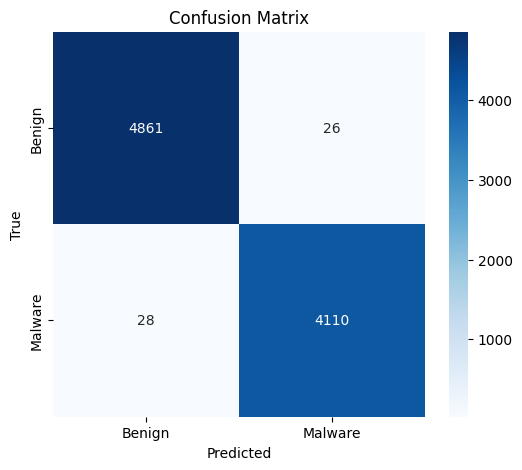

In [19]:
print("\n Normalized Model performance")
print(classification_report(all_labels,all_preds,target_names=['Benign','Malware']))

cm = confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot = True,fmt = 'd', cmap = 'Blues', xticklabels=['Benign','Malware'],yticklabels=['Benign','Malware'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Gradient calculations

--- Gradient Visualization Script (Normalized Model) ---
Using device: cuda
Disabling cuDNN to allow LSTM backward pass in eval mode...
Loading weights from best_model_normalized.pth...
Model loaded successfully.
Running forward pass...
Prediction Score: 0.9558
Backward pass complete.
Generating plots...


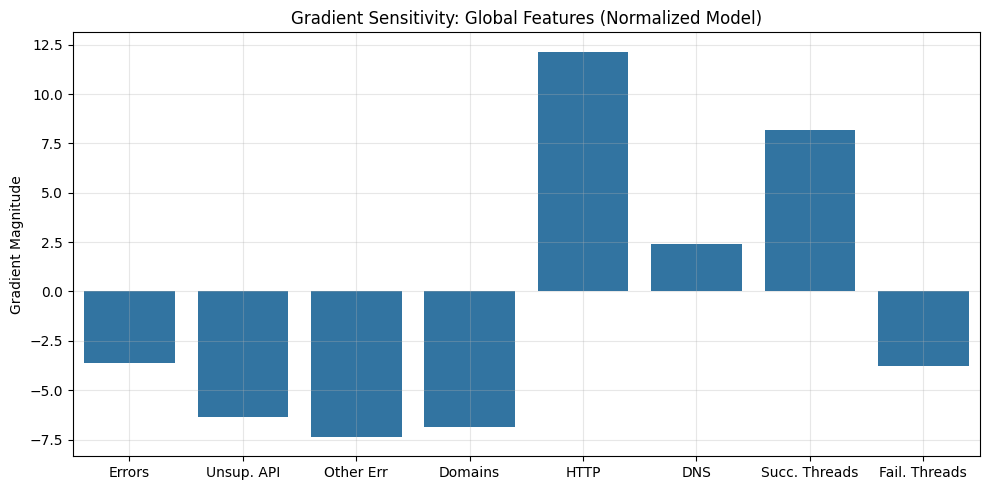

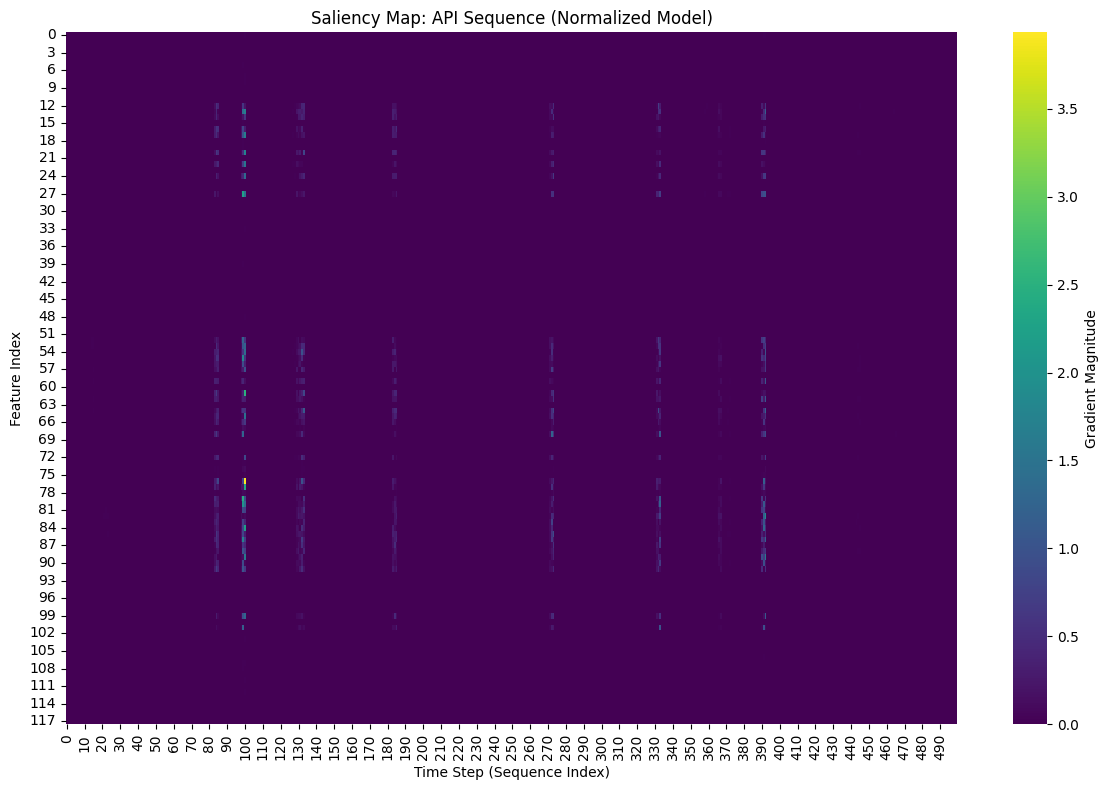

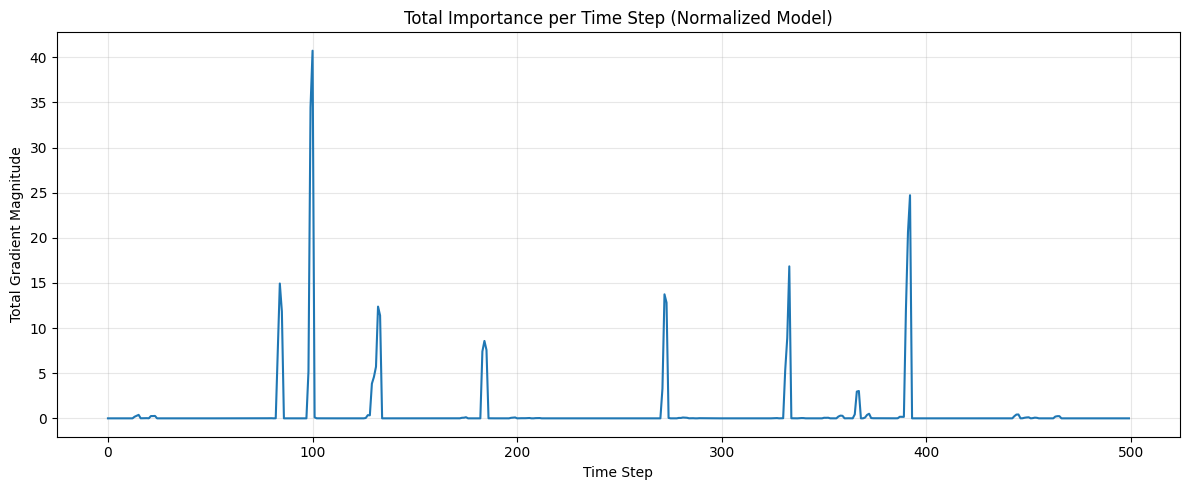

cuDNN re-enabled.


In [20]:
# --- Gradient Visualization (Normalized Model) ---
print("--- Gradient Visualization Script (Normalized Model) ---")

# 1. Configuration
NORM_MODEL_PATH = 'best_model_normalized.pth'
if not os.path.exists(NORM_MODEL_PATH) and os.path.exists(os.path.join('Neural_nets', NORM_MODEL_PATH)):
    NORM_MODEL_PATH = os.path.join('Neural_nets', NORM_MODEL_PATH)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# --- CRITICAL FIX: Disable cuDNN ---
# This allows us to run .backward() on an LSTM in .eval() mode
if torch.cuda.is_available():
    print("Disabling cuDNN to allow LSTM backward pass in eval mode...")
    torch.backends.cudnn.enabled = False

# 2. Load Model
# We can use standard initialization now (default dropout is fine because eval() turns it off)
viz_model = MalwareDetectionModel() 
viz_model.to(DEVICE)

# We use eval() mode!
# - Dropout is OFF (Deterministic)
# - BatchNorm uses running stats (Works with Batch Size 1)
viz_model.eval() 

if os.path.exists(NORM_MODEL_PATH):
    print(f"Loading weights from {NORM_MODEL_PATH}...")
    try:
        viz_model.load_state_dict(torch.load(NORM_MODEL_PATH, map_location=DEVICE))
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Error loading weights: {e}")
        print("Proceeding with random weights for demonstration.")
else:
    print(f"Warning: {NORM_MODEL_PATH} not found. Using random weights.")

# 3. Create Dummy Input (Normalized-like)
# Since we used Standard Scaling (Mean=0, Std=1), torch.randn is actually perfect!
api_input = torch.randn(1, 500, 118).to(DEVICE)
global_input = torch.randn(1, 8).to(DEVICE)

# 4. Enable Gradient Tracking
api_input.requires_grad = True
global_input.requires_grad = True

# 5. Forward Pass
print("Running forward pass...")
prediction = viz_model(api_input, global_input)
print(f"Prediction Score: {prediction.item():.4f}")

# 6. Backward Pass
criterion = nn.BCELoss()
# We want to see what pushes the score towards 0 (Benign) or 1 (Malware)
# Let's calculate gradient w.r.t the PREDICTION itself to see sensitivity
# Or simply backprop from a dummy target.
target = torch.zeros_like(prediction) # Target = 0 (Benign)
loss = criterion(prediction, target)

viz_model.zero_grad()
loss.backward()
print("Backward pass complete.")

# 7. Extract Gradients
api_grad = api_input.grad.data.cpu().numpy()[0] 
global_grad = global_input.grad.data.cpu().numpy()[0] 

# --- Plotting ---
print("Generating plots...")

# Plot 1: Global Features
global_feature_names = [
    "Errors", "Unsup. API", "Other Err",
    "Domains", "HTTP", "DNS",
    "Succ. Threads", "Fail. Threads"
]

plt.figure(figsize=(10, 5))
sns.barplot(x=global_feature_names, y=global_grad)
plt.title("Gradient Sensitivity: Global Features (Normalized Model)")
plt.ylabel("Gradient Magnitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: API Sequence Heatmap (Absolute Value)
plt.figure(figsize=(12, 8))
sns.heatmap(np.abs(api_grad).T, cmap="viridis", cbar_kws={'label': 'Gradient Magnitude'})
plt.title("Saliency Map: API Sequence (Normalized Model)")
plt.xlabel("Time Step (Sequence Index)")
plt.ylabel("Feature Index")
plt.tight_layout()
plt.show()

# Plot 3: Time Step Importance
time_step_importance = np.sum(np.abs(api_grad), axis=1)

plt.figure(figsize=(12, 5))
plt.plot(time_step_importance)
plt.title("Total Importance per Time Step (Normalized Model)")
plt.xlabel("Time Step")
plt.ylabel("Total Gradient Magnitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Re-enable cuDNN for future cells
if torch.cuda.is_available():
    torch.backends.cudnn.enabled = True
    print("cuDNN re-enabled.")

In [32]:

def manual_fgsm_attack(model, api_input, global_input, epsilon, target_label=0.0):
    api_adv = api_input.clone().detach().to(device)
    global_adv = global_input.clone().detach().to(device)
    api_adv.requires_grad = True
    global_adv.requires_grad = True
    prediction = model(api_adv, global_adv)
    criterion = nn.BCELoss()
    target = torch.full_like(prediction, target_label)
    loss = criterion(prediction, target)
    model.zero_grad()
    loss.backward()
    api_grad = api_adv.grad.data
    global_grad = global_adv.grad.data
    api_adv = api_adv - epsilon * api_grad.sign()
    global_adv = global_adv - epsilon * global_grad.sign()
    return api_adv, global_adv

def manual_pgd_attack(model, api_input, global_input, epsilon, alpha, num_iter, target_label=0.0):
    api_adv = api_input.clone().detach().to(device)
    global_adv = global_input.clone().detach().to(device)
    for t in range(num_iter):
        api_adv.requires_grad = True
        global_adv.requires_grad = True
        prediction = model(api_adv, global_adv)
        criterion = nn.BCELoss()
        target = torch.full_like(prediction, target_label)
        loss = criterion(prediction, target)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            api_adv = api_adv - alpha * api_adv.grad.sign()
            global_adv = global_adv - alpha * global_adv.grad.sign()
            delta_api = api_adv - api_input
            delta_api = torch.clamp(delta_api, -epsilon, epsilon)
            api_adv = api_input + delta_api
            delta_global = global_adv - global_input
            delta_global = torch.clamp(delta_global, -epsilon, epsilon)
            global_adv = global_input + delta_global
    return api_adv, global_adv

In [33]:
norm_model_path = os.path.join(OUTPUT_DIR, 'best_model_normalized.pth')
norm_model = MalwareDetectionModel().to(device)


In [34]:
norm_model.load_state_dict(torch.load(norm_model_path,map_location=device))
norm_model.eval()
if torch.cuda.is_available():
    torch.backends.cudnn.enabled = False

In [40]:
Attack_samples= 20
eps = 0.5
alpha = eps/10
iter = 20

train_files = splits['test']['files']
train_lables = splits['test']['labels']

malware_indices = [i for i , label in enumerate(train_lables) if label == 1]
selected_indices = malware_indices
selected_files = [train_files[i] for i in selected_indices]
selected_labels = [train_lables[i] for i in selected_indices]

logging.info(f"Selected {len(selected_files)} and lables{selected_labels}")

2025-12-30 17:12:37,910 - INFO - Selected 4138 and lables[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [42]:
attack_dataset = NormalizedMalwareDataset(selected_files,selected_labels,api_mean,api_std,global_mean,global_std)
attack_loader= DataLoader(attack_dataset,batch_size=1,shuffle=False)

In [43]:
print(f"\n{'ID':<5} | {'Original':<10} | {'FGSM':<10} | {'PGD':<10} | {'Status':<15}")
print("-" * 60)
fgsm_success_count = 0
pgd_success_count = 0

for i,((api_sample,global_sample),label) in enumerate(attack_loader):
    api_sample, global_sample = api_sample.to(device),global_sample.to(device)

    with torch.no_grad():
        orig_score = norm_model(api_sample,global_sample).item()
    
    adv_api_fgsm,adv_global_fgsm = manual_fgsm_attack(
        norm_model,api_sample, global_sample, eps
    )
    with torch.no_grad():
        fgsm_score = norm_model(adv_api_fgsm,adv_global_fgsm).item()
    
    adv_api_pgd, adv_global_pgd = manual_pgd_attack(
        norm_model, api_sample, global_sample, eps, alpha, iter
    )
    with torch.no_grad():
        pgd_score = norm_model(adv_api_pgd,adv_global_pgd).item()
    
    fgsm_evaded = fgsm_score<0.5
    pgd_evaded = pgd_score<0.5

    if fgsm_evaded : fgsm_success_count+=1
    if pgd_evaded : pgd_success_count+=1

    status = []
    if fgsm_evaded: status.append("FGSM")
    if pgd_evaded: status.append("PGD")
    status_str = "+".join(status) if status else "Failed"
    
    print(f"{i:<5} | {orig_score:<10.4f} | {fgsm_score:<10.4f} | {pgd_score:<10.4f} | {status_str:<15}")
print("-" * 60)
print(f"FGSM Success Rate: {fgsm_success_count}/{Attack_samples} ({fgsm_success_count/Attack_samples*100:.1f}%)")
print(f"PGD Success Rate:  {pgd_success_count}/{Attack_samples} ({pgd_success_count/Attack_samples*100:.1f}%)")


ID    | Original   | FGSM       | PGD        | Status         
------------------------------------------------------------
0     | 1.0000     | 0.9494     | 0.1481     | PGD            
1     | 1.0000     | 1.0000     | 1.0000     | Failed         
2     | 1.0000     | 0.8735     | 0.2278     | PGD            
3     | 1.0000     | 0.9398     | 0.1432     | PGD            
4     | 1.0000     | 0.9077     | 0.1335     | PGD            
5     | 1.0000     | 0.9703     | 0.2138     | PGD            
6     | 1.0000     | 0.8805     | 0.1981     | PGD            
7     | 1.0000     | 0.8803     | 0.2244     | PGD            
8     | 1.0000     | 1.0000     | 1.0000     | Failed         
9     | 1.0000     | 0.8792     | 0.0772     | PGD            
10    | 1.0000     | 0.8813     | 0.2242     | PGD            
11    | 1.0000     | 0.8792     | 0.0772     | PGD            
12    | 1.0000     | 1.0000     | 1.0000     | Failed         
13    | 1.0000     | 0.7110     | 0.1473     | PGD      

KeyboardInterrupt: 

In [ ]:

ADV_OUTPUT_DIR = 'adversarial_samples_test'
os.makedirs(os.path.join(ADV_OUTPUT_DIR, 'fgsm'), exist_ok=True)
os.makedirs(os.path.join(ADV_OUTPUT_DIR, 'pgd'), exist_ok=True)

print(f"\n{'ID':<5} | {'Original':<10} | {'FGSM':<10} | {'PGD':<10} | {'Status':<15}")
print("-" * 60)
fgsm_success_count = 0
pgd_success_count = 0


for i, ((api_sample, global_sample), label) in enumerate(attack_loader):
    api_sample, global_sample = api_sample.to(device), global_sample.to(device)

    # Get original filename for saving
    original_path = selected_files[i]['apis']
    base_name = os.path.basename(original_path).replace('_apis.npy', '')

    with torch.no_grad():
        orig_score = norm_model(api_sample, global_sample).item()
    

    adv_api_fgsm, adv_global_fgsm = manual_fgsm_attack(
        norm_model, api_sample, global_sample, eps
    )
    with torch.no_grad():
        fgsm_score = norm_model(adv_api_fgsm, adv_global_fgsm).item()
    
    
    np.save(os.path.join(ADV_OUTPUT_DIR, 'fgsm', f"{base_name}_apis.npy"), adv_api_fgsm.cpu().detach().numpy()[0])
    np.save(os.path.join(ADV_OUTPUT_DIR, 'fgsm', f"{base_name}_globals.npy"), adv_global_fgsm.cpu().detach().numpy()[0])

    
    adv_api_pgd, adv_global_pgd = manual_pgd_attack(
        norm_model, api_sample, global_sample, eps, alpha, iter
    )
    with torch.no_grad():
        pgd_score = norm_model(adv_api_pgd, adv_global_pgd).item()
    
    
    np.save(os.path.join(ADV_OUTPUT_DIR, 'pgd', f"{base_name}_apis.npy"), adv_api_pgd.cpu().detach().numpy()[0])
    np.save(os.path.join(ADV_OUTPUT_DIR, 'pgd', f"{base_name}_globals.npy"), adv_global_pgd.cpu().detach().numpy()[0])

    
    fgsm_evaded = fgsm_score < 0.5
    pgd_evaded = pgd_score < 0.5

    if fgsm_evaded: fgsm_success_count += 1
    if pgd_evaded: pgd_success_count += 1

    status = []
    if fgsm_evaded: status.append("FGSM")
    if pgd_evaded: status.append("PGD")
    status_str = "+".join(status) if status else "Failed"
    
    print(f"{i:<5} | {orig_score:<10.4f} | {fgsm_score:<10.4f} | {pgd_score:<10.4f} | {status_str:<15}")

print("-" * 60)
print(f"FGSM Success Rate: {fgsm_success_count}/{len(selected_files)} ({fgsm_success_count/len(selected_files)*100:.1f}%)")
print(f"PGD Success Rate:  {pgd_success_count}/{len(selected_files)} ({pgd_success_count/len(selected_files)*100:.1f}%)")
print(f"Adversarial samples saved to {ADV_OUTPUT_DIR}/")


ID    | Original   | FGSM       | PGD        | Status         
------------------------------------------------------------
0     | 1.0000     | 0.9494     | 0.1481     | PGD            
1     | 1.0000     | 1.0000     | 1.0000     | Failed         
2     | 1.0000     | 0.8735     | 0.2278     | PGD            
3     | 1.0000     | 0.9398     | 0.1432     | PGD            
4     | 1.0000     | 0.9077     | 0.1335     | PGD            
5     | 1.0000     | 0.9703     | 0.2138     | PGD            
6     | 1.0000     | 0.8805     | 0.1981     | PGD            
7     | 1.0000     | 0.8803     | 0.2244     | PGD            
8     | 1.0000     | 1.0000     | 1.0000     | Failed         
9     | 1.0000     | 0.8792     | 0.0772     | PGD            
10    | 1.0000     | 0.8813     | 0.2242     | PGD            
11    | 1.0000     | 0.8792     | 0.0772     | PGD            
12    | 1.0000     | 1.0000     | 1.0000     | Failed         
13    | 1.0000     | 0.7110     | 0.1473     | PGD      